# Samit Bhisikar
## Lab5-KNN
## A3-33

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score,StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [44]:
df = pd.read_csv('/content/diabetes (6).csv')
df.head()
df.tail()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


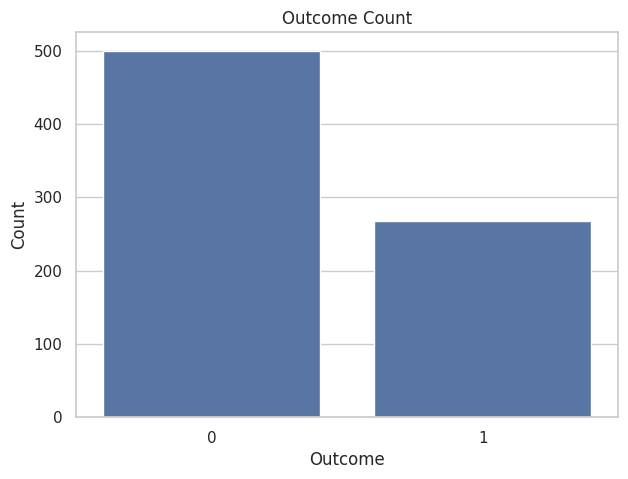

In [45]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x=df['Outcome']
)
plt.title('Outcome Count')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

In [46]:
zero_columns=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
zero_counts=(df[zero_columns]==0).sum()

print("Zero Values:")
print(zero_counts)

Zero Values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [47]:
df_clean=df.copy()
df_clean[zero_columns]=df_clean[zero_columns].replace(0,np.nan)
print("Missing values after replacing invalid zeroes:")
print(df_clean.isnull().sum())

Missing values after replacing invalid zeroes:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [48]:
for col in zero_columns:
  df_clean[col]=df_clean[col].fillna(df_clean[col].median())

print("Missing values after filling with median:")
print(df_clean.isnull().sum())

Missing values after filling with median:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Data Visualization after Cleaning

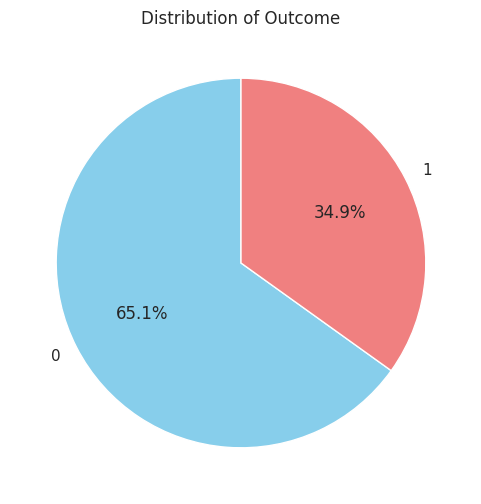

In [49]:
plt.figure(figsize=(6, 6))
df_clean['Outcome'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Outcome')
plt.ylabel('')
plt.show()

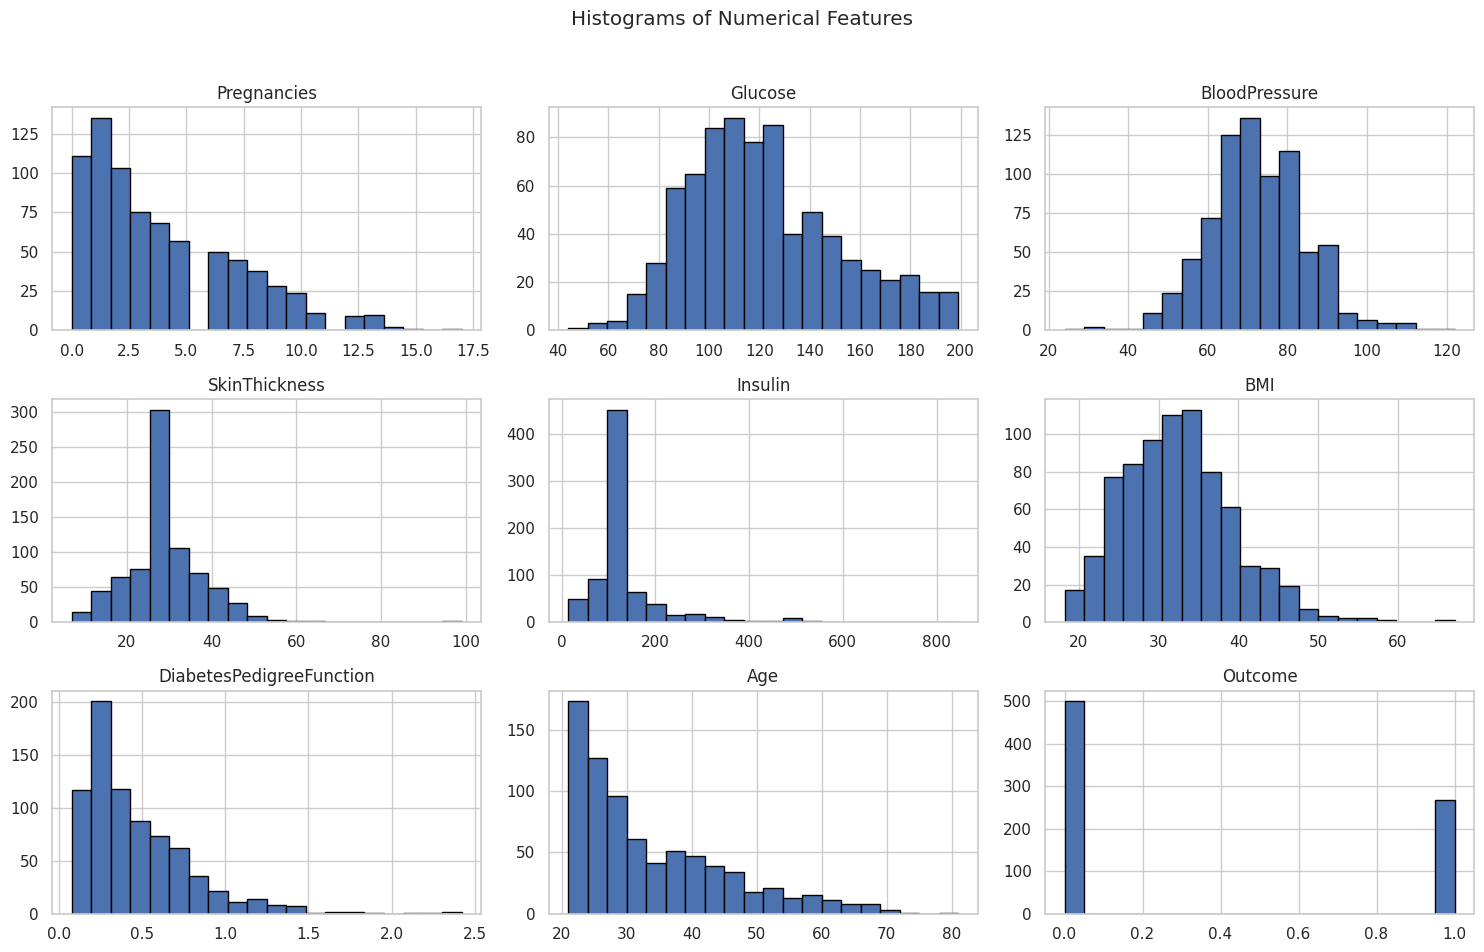

In [50]:
df_clean.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

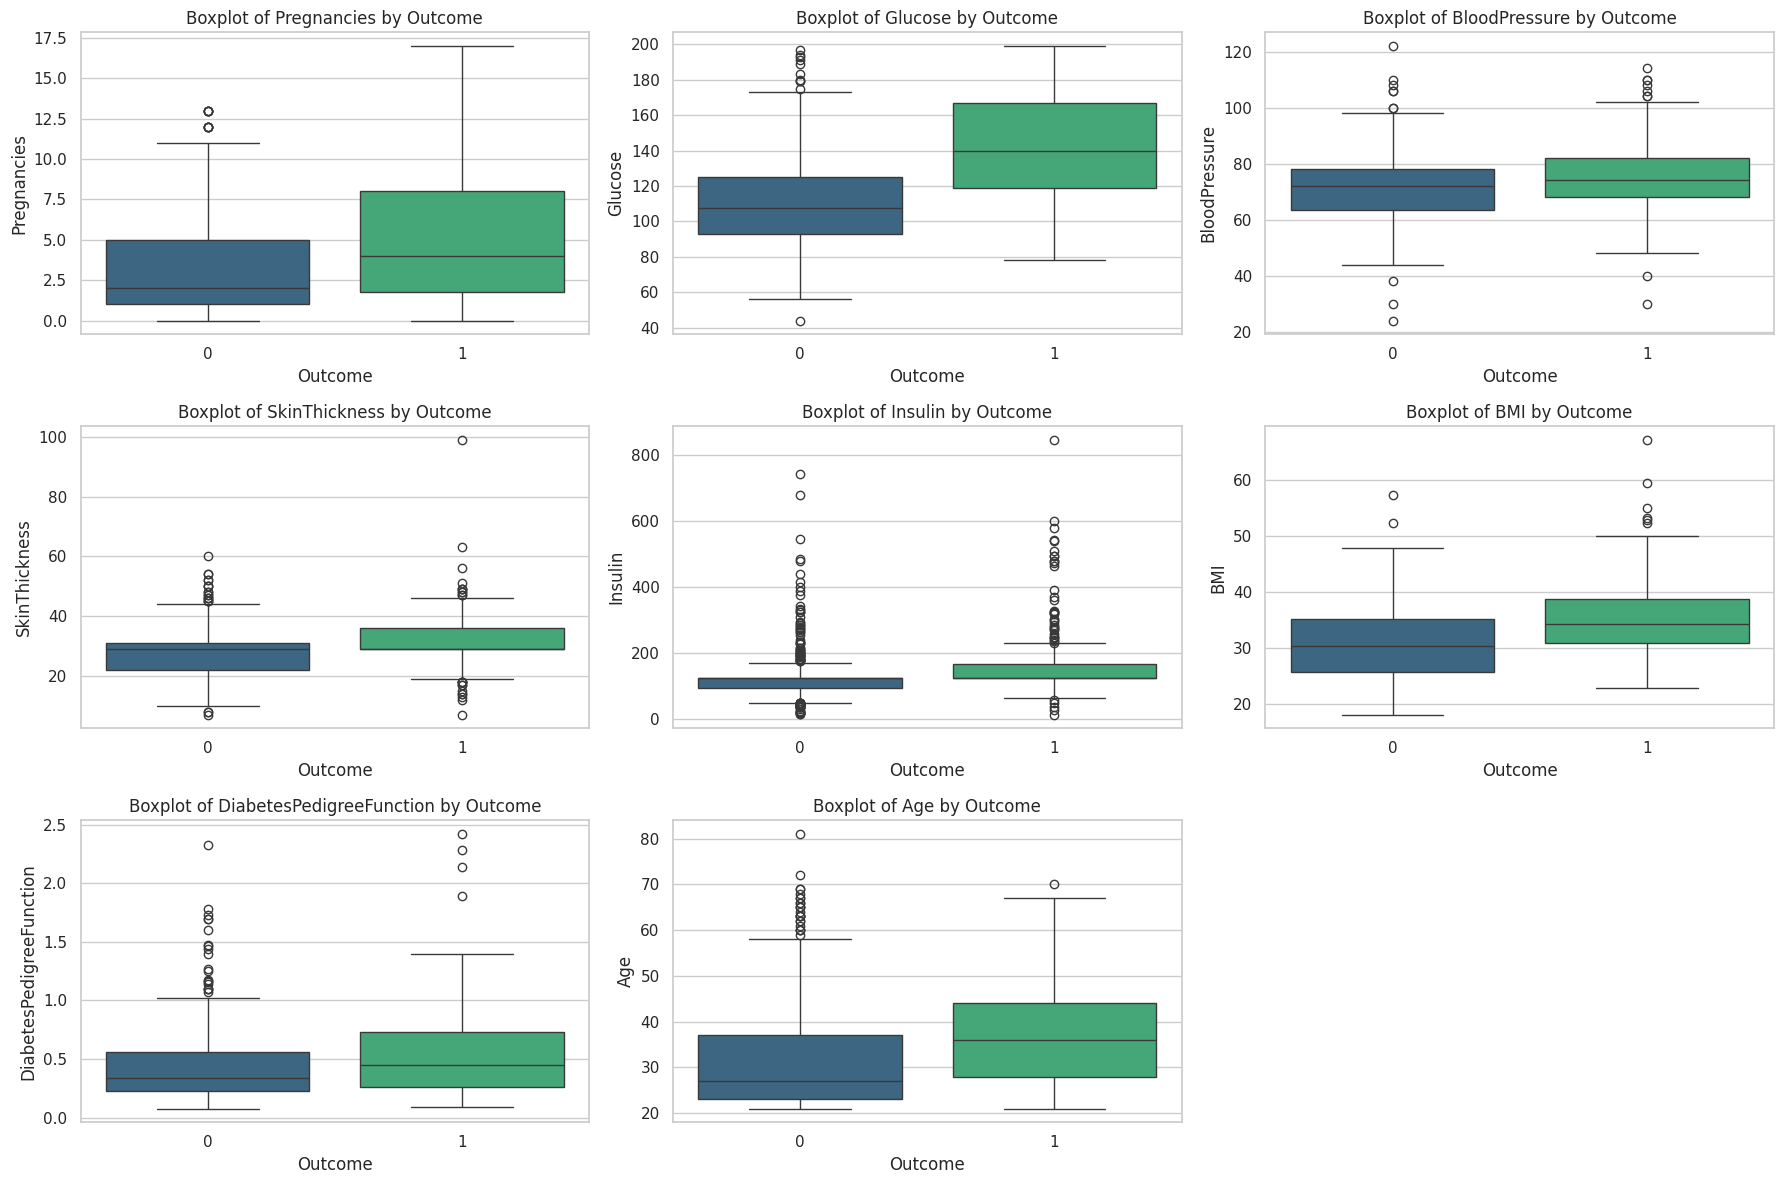

In [51]:
plt.figure(figsize=(18, 12))
for i, column in enumerate(df_clean.columns[:-1]):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='Outcome', y=column, data=df_clean, palette='viridis')
    plt.title(f'Boxplot of {column} by Outcome')
plt.tight_layout()
plt.show()

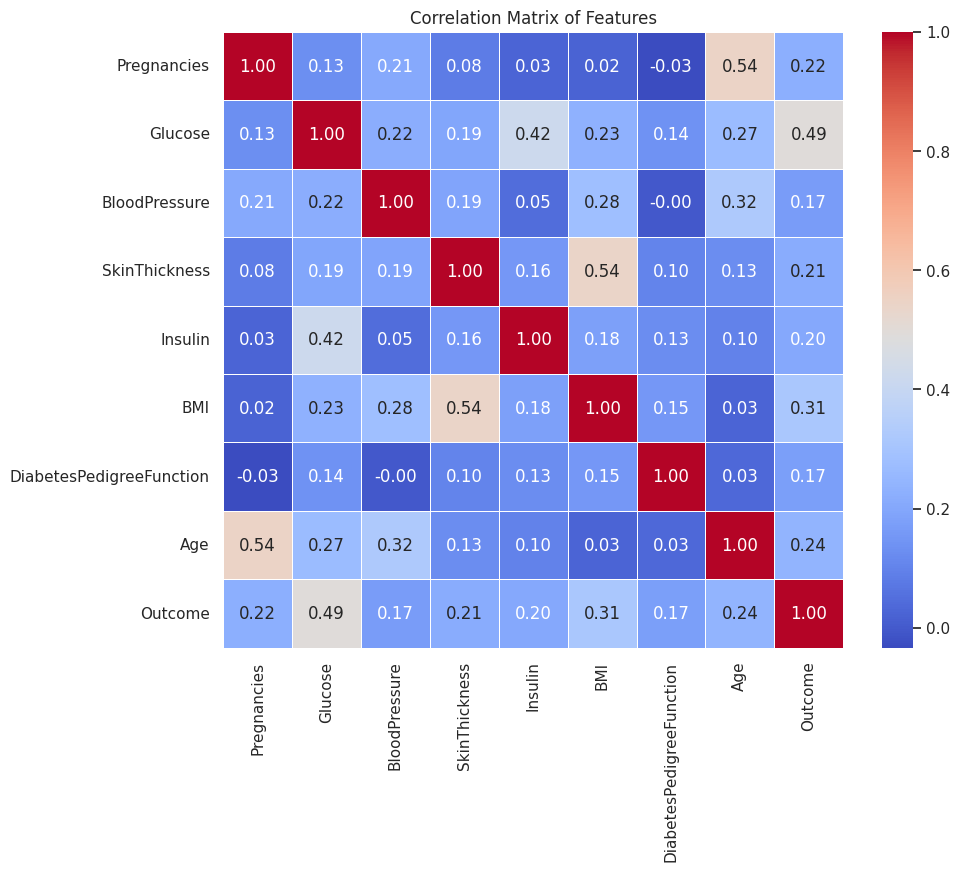

In [52]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()

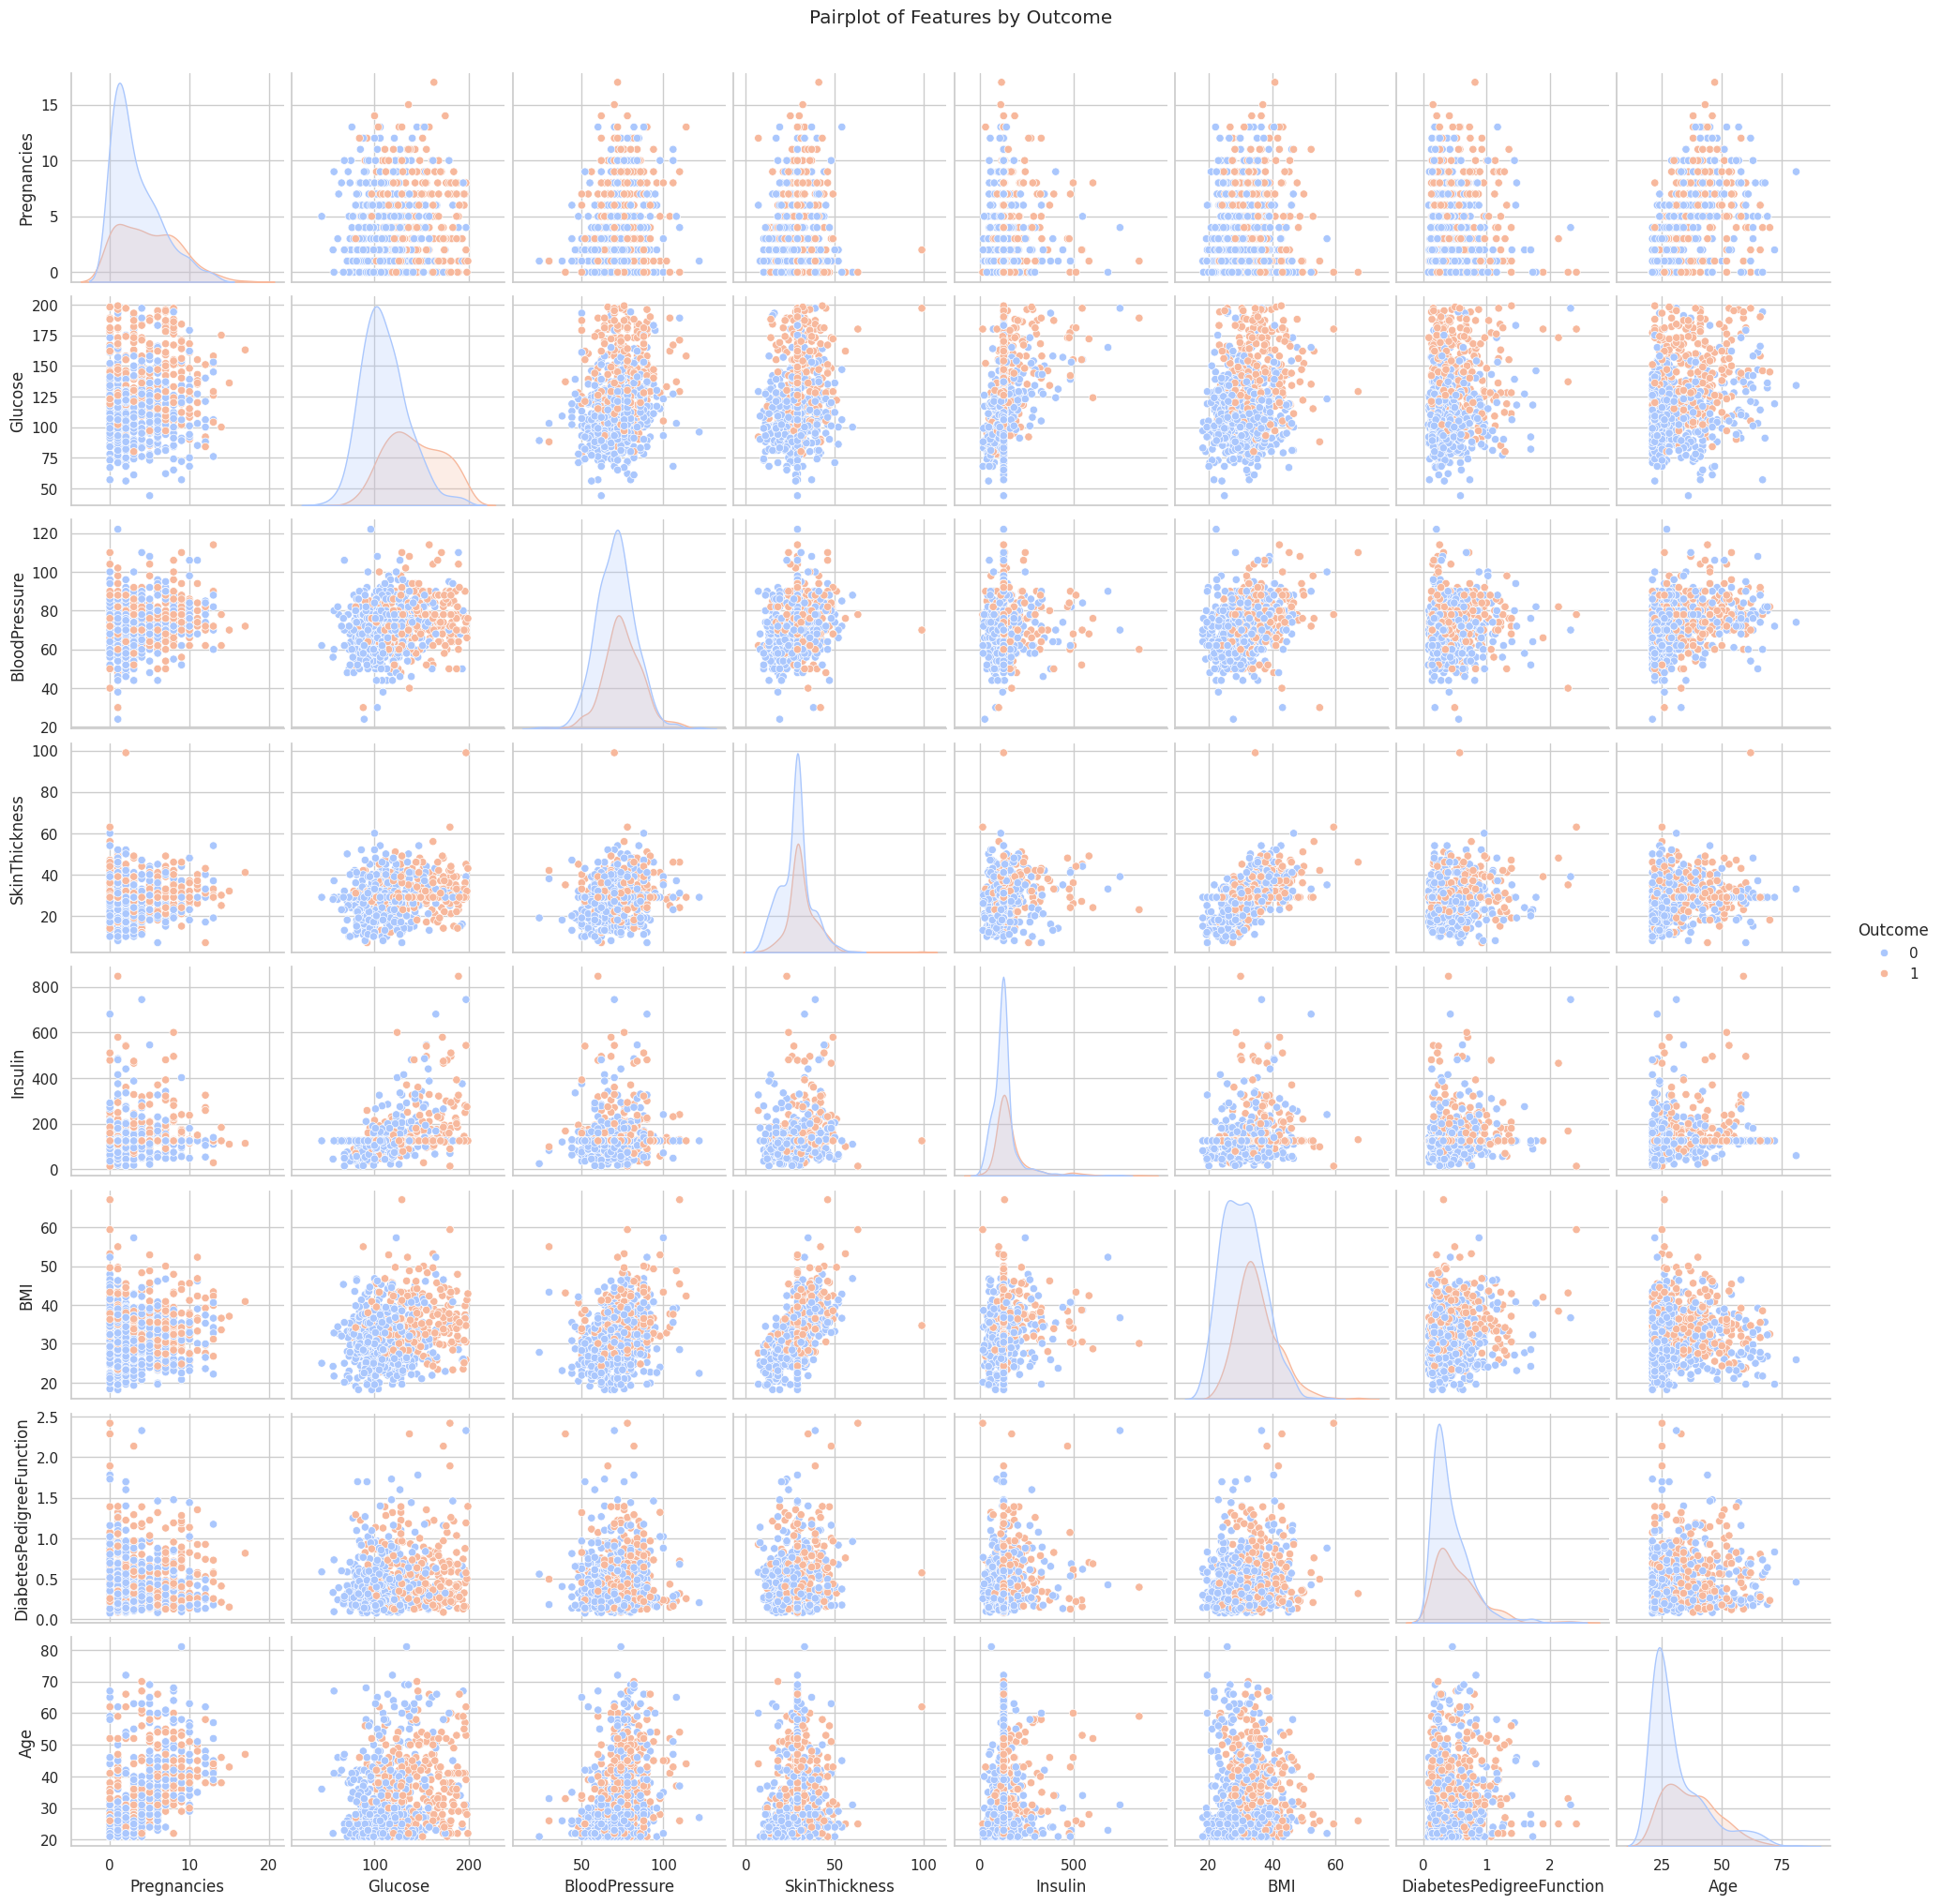

In [53]:
sns.pairplot(df_clean, hue='Outcome', palette='coolwarm', diag_kind='kde')
plt.suptitle('Pairplot of Features by Outcome', y=1.02)
plt.show()

In [54]:
X=df_clean.drop('Outcome',axis=1)
y=df_clean['Outcome']

print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (768, 8)
y shape: (768,)


In [55]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training samples:",X_train.shape[0])
print("testing samples:",X_test.shape)

Training samples: 614
testing samples: (154, 8)


In [56]:
print("Training samples:")
print(y_train.value_counts(normalize=True))
print("\nTesting samples:")
print(y_test.value_counts(normalize=True))

Training samples:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing samples:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [57]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
scaler.fit_transform(X_test)
scaler.transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [58]:
comparison=pd.DataFrame({
    "Original Mean":X_train.mean(),
    "Original Std":X_train.std(),
    "Scaled Mean":X_train_scaled.mean(axis=0),
    "Scaled Std":X_train_scaled.std(axis=0)
})
display(comparison)

,Original Mean,Original Std,Scaled Mean,Scaled Std
Pregnancies,3.819218,3.314148,-6.943414e-17,1.0
Glucose,121.671010,30.003794,-1.099374e-16,1.0
BloodPressure,72.140065,12.275119,3.095606e-16,1.0
SkinThickness,29.042345,8.891855,-3.471707e-17,1.0
Insulin,137.705212,78.764767,-4.339634e-18,1.0
BMI,32.446743,6.824142,-1.148556e-15,1.0
DiabetesPedigreeFunction,0.477428,0.330300,-1.099374e-16,1.0
Age,33.366450,11.833438,-1.084908e-16,1.0


In [59]:
K=5
knn=KNeighborsClassifier(n_neighbors=K)
knn.fit(X_train_scaled,y_train)
y_pred=knn.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0]


In [60]:
y_prob=knn.predict_proba(X_test_scaled)[:,1]

print(y_prob[:20])

[0.6 0.2 0.2 0.6 0.  0.2 0.2 0.8 0.  0.6 0.4 0.6 0.  0.  0.  0.6 0.8 0.
 1.  0.2]


In [61]:
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy:.4f}")

precision=precision_score(y_test,y_pred)
print(f"Precision:{precision:.4f}")

recall=recall_score(y_test,y_pred)
print(f"Recall:{recall:.4f}")

f1=f1_score(y_test,y_pred)
print(f"F1 Score:{f1:.4f}")


Accuracy:0.7532
Precision:0.6600
Recall:0.6111
F1 Score:0.6346


In [62]:
print(classification_report(y_test,y_pred,target_names=['No Diabetes','Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [63]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[83 17]
 [21 33]]


Text(0.5, 1.0, 'KNN Confusion Matrix')

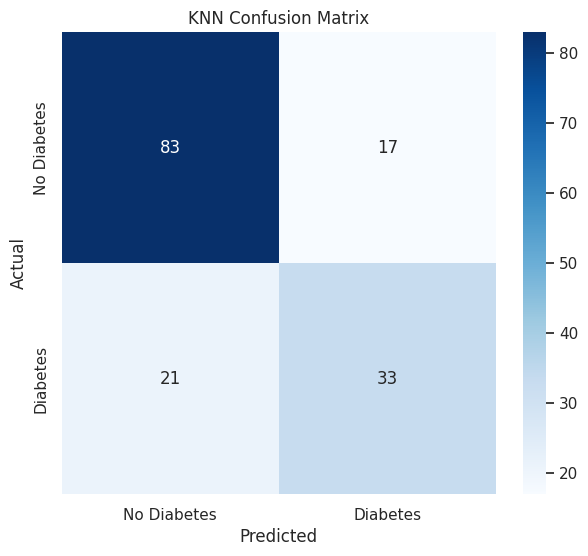

In [64]:
plt.figure(figsize=(7,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Diabetes','Diabetes'],yticklabels=['No Diabetes','Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("KNN Confusion Matrix")

In [65]:
k_values=range(1,31)

train_accuracy=[]
test_accuracy=[]

for k in k_values:
  model=KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train_scaled,y_train)
  train_accuracy.append(model.score(X_train_scaled,y_train))
  test_accuracy.append(model.score(X_test_scaled,y_test))

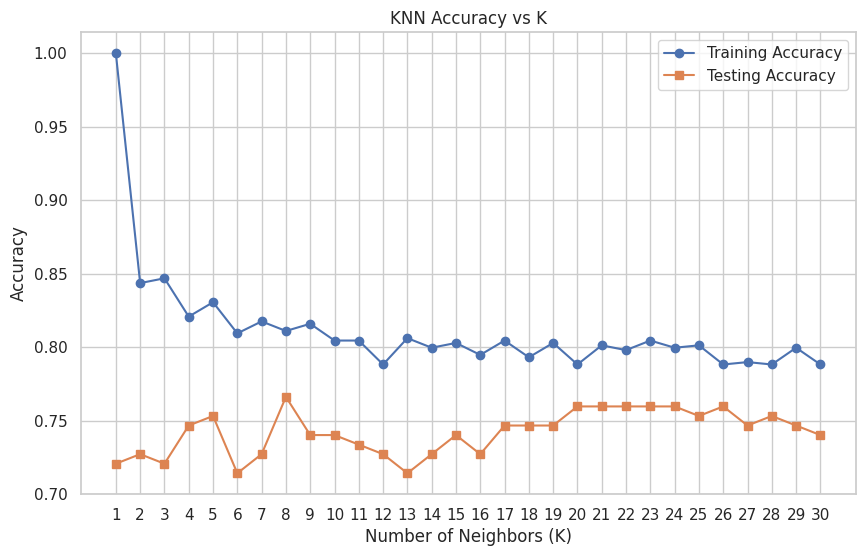

In [66]:
plt.figure(figsize=(10,6))
plt.plot(k_values,train_accuracy,marker="o",label='Training Accuracy')
plt.plot(k_values,test_accuracy,marker="s",label='Testing Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.xticks(k_values)
plt.legend()
plt.show()

In [67]:
best_k_accuracy=k_values[np.argmax(test_accuracy)]
best_accuracy=max(test_accuracy)

print(f"Best K value: {best_k_accuracy}")
print(f"Best test accuracy: {best_accuracy}")

Best K value: 8
Best test accuracy: 0.7662337662337663


In [68]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=[]

for k in range(1,31):
  model=KNeighborsClassifier(n_neighbors=k)
  scores=cross_val_score(model,X_train_scaled,y_train,cv=cv,scoring='accuracy')
  cv_scores.append(scores.mean())

Text(0, 0.5, 'Cross-Validation Accuracy')

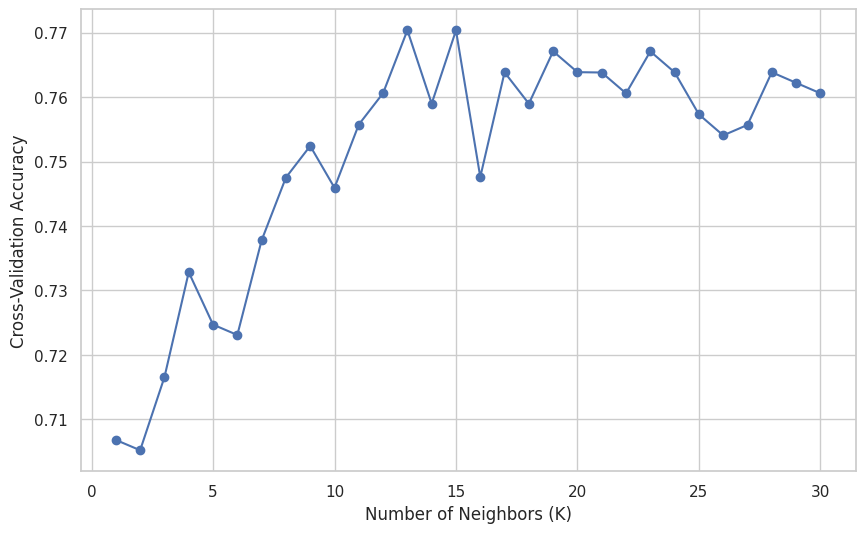

In [69]:
plt.figure(figsize=(10,6))
plt.plot(range(1,31),cv_scores,marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validation Accuracy')

In [70]:
best_k_cv=np.argmax(cv_scores)+1
print(f"Best K value based on cross-validation: {best_k_cv}")
print(f"Best cross-validation accuracy: {max(cv_scores)}")

Best K value based on cross-validation: 13
Best cross-validation accuracy: 0.7703718512594963


In [71]:
param_grid={"n_neighbors":list(range(3,31,2)),"weights":["uniform","distance"],
    "metric":["euclidean","manhattan","minkowski"],
    "p":[1,2]
}

In [72]:
grid_search=GridSearchCV(estimator=KNeighborsClassifier(),param_grid=param_grid,cv=5,scoring="accuracy",n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)
print("Grid search completed")

Grid search completed


In [73]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'metric': 'euclidean', 'n_neighbors': 19, 'p': 1, 'weights': 'uniform'}


In [74]:
print("Best accuracy:")
print(grid_search.best_score_)

Best accuracy:
0.7769025723044115
